### Create AnnData object for GSE23672 — Muñoz 2012 canonical Lgr5⁺ ISC microarray signature

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData (samples × genes) from the 4 Agilent 2-channel microarray FE files at `LGR5_analysis_data/GSE23672/` (platform GPL4134, 4×44K Whole Mouse Genome). Loaded via `utils.agilent_fe.load_agilent_study`, which parses the `LogRatio` column (log2 red/green) and aggregates probes to genes by mean.

Muñoz 2012 design: FACS-sorted **Lgr5-EGFP-high** stem cells vs **Lgr5-EGFP-low** daughter cells from Lgr5-EGFP-IRES-CreERT2 mice, 2 replicates per gate.

⚠️ **Per-GSM hi/lo assignment is a best-guess by GSM order** — `GSM580637/8 = LGR5-EGFP-high`, `GSM580639/40 = LGR5-EGFP-low`. Verify against the GEO sample metadata (`https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE23672`) and patch `SAMPLE_META` below before relying on this AnnData for biology. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §7).

### Import packages

In [1]:
import os, sys
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc

# repo-local utility (run notebooks from repo root)
sys.path.insert(0, os.getcwd())
from utils.agilent_fe import load_agilent_study

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Per-sample metadata

Best-guess hi/lo split by GSM order (see the warning above).

In [2]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE23672'

SAMPLE_PATHS = {
    'GSM580637': os.path.join(DATA_DIR, 'GSM580637.txt.gz'),
    'GSM580638': os.path.join(DATA_DIR, 'GSM580638.txt.gz'),
    'GSM580639': os.path.join(DATA_DIR, 'GSM580639.txt.gz'),
    'GSM580640': os.path.join(DATA_DIR, 'GSM580640.txt.gz'),
}

SAMPLE_META = {
    # Empirical Lgr5 LogRatio per GSM (verified by running the parser): 637=+0.63, 638=-0.57, 639=-0.61, 640=+0.74
    # → high = 637, 640; low = 638, 639 (likely a dye-swap pairing rather than consecutive replicates)
    'GSM580637': dict(sample='Lgr5-EGFP-hi_rep1',  lgr5_status='LGR5+', lgr5_label_raw='Lgr5-EGFP-high', condition='Lgr5-EGFP-high', cell_type='Lgr5+ ISC',          tissue='small intestine', GSE='GSE23672', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM580638': dict(sample='Lgr5-EGFP-lo_rep1',  lgr5_status='LGR5-', lgr5_label_raw='Lgr5-EGFP-low',  condition='Lgr5-EGFP-low',  cell_type='Lgr5-low daughter', tissue='small intestine', GSE='GSE23672', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM580639': dict(sample='Lgr5-EGFP-lo_rep2',  lgr5_status='LGR5-', lgr5_label_raw='Lgr5-EGFP-low',  condition='Lgr5-EGFP-low',  cell_type='Lgr5-low daughter', tissue='small intestine', GSE='GSE23672', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
    'GSM580640': dict(sample='Lgr5-EGFP-hi_rep2',  lgr5_status='LGR5+', lgr5_label_raw='Lgr5-EGFP-high', condition='Lgr5-EGFP-high', cell_type='Lgr5+ ISC',          tissue='small intestine', GSE='GSE23672', organism='mus musculus', technology='Agilent 2-color microarray (GPL4134)', assay_modality='microarray'),
}

### Parse the FE files and build the AnnData

In [3]:
adata = load_agilent_study(SAMPLE_PATHS, SAMPLE_META, value_column='LogRatio', aggregate='mean')
for col in ['sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'GSE', 'organism', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata

AnnData object with n_obs × n_vars = 4 × 27827
    obs: 'sample', 'lgr5_status', 'lgr5_label_raw', 'condition', 'cell_type', 'tissue', 'GSE', 'organism', 'technology', 'assay_modality'
    var: 'n_probes'
    uns: 'agilent_value_column', 'agilent_aggregate', 'agilent_n_channels'

### Sanity check — Lgr5 / Olfm4 / Ascl2 LogRatio in hi vs lo

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2074: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in [*adata.obs_keys(), adata.obs.index.name]:


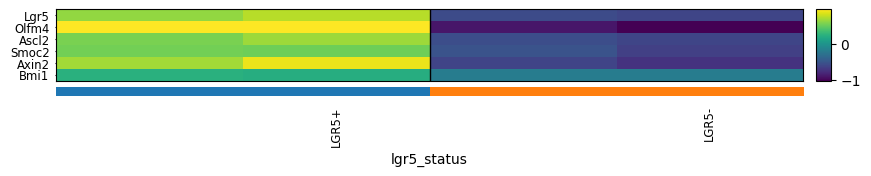

In [4]:
isc_markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Smoc2', 'Axin2', 'Bmi1'] if g in adata.var_names]
if isc_markers:
    sc.pl.heatmap(adata, var_names=isc_markers, groupby='lgr5_status', swap_axes=True, dendrogram=False)

### Save

In [5]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE23672'
adata.uns['publication'] = 'Muñoz J et al., EMBO J 31:3079-3091 (2012) — The Lgr5 intestinal stem cell signature'
adata.uns['genome_reference'] = 'GPL4134 — Agilent Whole Mouse Genome Microarray 4x44K v2 (probe annotation in agilent_fe parser output)'
adata.uns['source_files'] = sorted([os.path.basename(p) for p in SAMPLE_PATHS.values()] + ['GPL4134_old_annotations.txt.gz'])
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from 4 Agilent 2-channel FE files; LogRatio extracted; per-gene mean across probes; lgr5_status assigned by best-guess GSM order (verify against GEO metadata). | note: X holds log2(red/green) ratios per probe-aggregated gene, NOT raw counts. Downstream tools that assume integer counts (e.g. Scrublet, scVI) will not work without first converting to a per-channel intensity layer.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE23672_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE23672_AM_07052026_230704_raw.h5ad (4, 27827)
